In [1]:
from typing import Dict, List
import numpy as np
import pandas as pd
from scipy.stats import pearsonr # pyright: ignore[reportMissingTypeStubs, reportUnknownVariableType]

from model_ranking.results import (
    get_summary_results, 
    per_source_model_results,
    results_to_arrays,
)
from model_ranking.plots import plot_alpha_sweep_specific_norm
from model_ranking.correlation import (
    scores_to_rank, 
    permutation_test_kendall_tau, 
    permutation_test_spearman_rho,
)

In [4]:
NA_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}
source_models={
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys2 = {
    "EPFL": "EI_th05",
    "Hmito": "EI_th05",
    "Rmito": "EI_th05",
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}
selected_augmentations = {
    "none": [""],
    "DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04"],
}
invert_consis = False
invert_perf = False
rank_ascending = False
perf_tolerance = 0
consis_tolerance = 0
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito", "VNC"]
targets = ["EPFL"]
#targets = ["VNC"]
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
summary_results_postfix = "_full"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 25.22it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 25.89it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 26.19it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  7.30it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00,  4.43it/s]


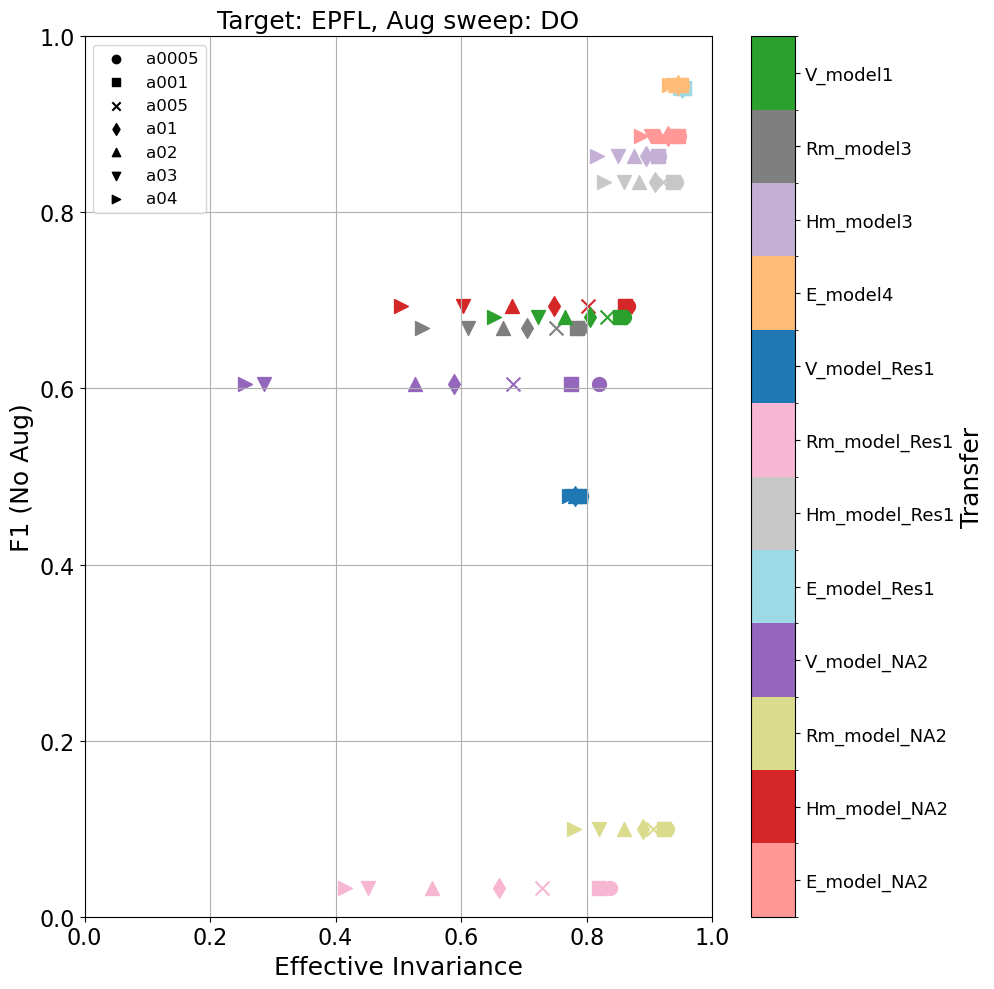

In [7]:
single_target_consistency = {}
single_target_performance = {}
kendall_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
k_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
spearman_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
sp_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
pearson_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
p_pval_per_transfer = np.zeros((len(targets), len(selected_augmentations["DO"])))
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_consistency = {}
    per_source_performance = {}
    consis_str_NAmodels, _, NA_perf_NAmodels = get_summary_results(
        source_data=sources,
        #source_data=["EPFL", "Hmito", "VNC"],
        target_data=[target],
        source_models = NA_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_consistency.update(
        per_source_model_results(
            consis_str_NAmodels, 
            source_models=NA_source_models, 
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf_NAmodels, 
            source_models=NA_source_models,
        ))
    
    consis_str_Resmodels, _, NA_perf_Resmodels = get_summary_results(
        source_data=sources,
        #source_data=["EPFL", "Hmito", "VNC"],
        target_data=[target],
        source_models = Res_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_consistency.update(
        per_source_model_results(
            consis_str_Resmodels, 
            source_models=Res_source_models, 
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf_Resmodels, 
            source_models=Res_source_models,
        ))
    
    if target == "VNC":
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders={"VNC": "resized"},
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
    else:
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys2,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        consis_str_VNC, _, NA_per_VNC = get_summary_results(
            source_data=["VNC"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        consis_str.update(consis_str_VNC)
        NA_perf.update(NA_per_VNC)
    
    per_source_consistency.update(
        per_source_model_results(
            consis_str, 
            source_models=source_models,
        ))
    per_source_performance.update(
        per_source_model_results(
            NA_perf,
            source_models=source_models,
        ))
    
    single_target_consistency[target] = per_source_consistency
    single_target_performance[target] = per_source_performance

    plot_alpha_sweep_specific_norm(
        per_source_consistency,
        per_source_performance,
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

    consis_scores, NA_perf_scores = results_to_arrays(
        per_source_consistency, per_source_performance, "DO", len(selected_augmentations["DO"])
    )
    if invert_consis:
        consis_scores = 1 - consis_scores
    if invert_perf:
        NA_perf_scores = 1 - NA_perf_scores

    target_df = pd.DataFrame()
    target_df['aug_strength'] = selected_augmentations["DO"]
    ken_scores = np.zeros(consis_scores.shape[1])
    ken_pvalue = np.zeros(consis_scores.shape[1])
    spear_scores = np.zeros(consis_scores.shape[1])
    spear_pval = np.zeros(consis_scores.shape[1])
    pearsons_scores = np.zeros(consis_scores.shape[1])
    pearsons_pval = np.zeros(consis_scores.shape[1])
    for j in range(consis_scores.shape[1]):
        #print(f"Consis Tolerance {consis_tolerance}")
        #print(f"Aug strength {selected_augmentations['DO'][j]}, Target {target}")
        #print(f"performance scores { NA_perf_scores}")
        ranked_scores = scores_to_rank(NA_perf_scores, ascending=rank_ascending, tolerance=perf_tolerance)
        #print(f"ranked scores {ranked_scores}")
        #print(f"consistency scores {consis_scores[:, j]}")
        ranked_consis = scores_to_rank(consis_scores[:, j],ascending=rank_ascending, tolerance=consis_tolerance)
        #print(f"ranked consistency {ranked_consis}")
        #pearson, spearman, kendall = prediction_correlation(ranked_scores, consis_scores[:, i])
        pearson, pearson_pval = pearsonr(NA_perf_scores, consis_scores[:,j])
        spearman, spearmans_pval = permutation_test_spearman_rho(ranked_scores, ranked_consis)
        ken, pval = permutation_test_kendall_tau(ranked_scores, ranked_consis)
        #pearson, spearman, kendall = prediction_correlation(ranked_scores, ranked_consis)
        #print(f"{selected_augmentations['DO'][j]}: p={pearson:.3f}, s={spearman:.3f}, k{ken:.3f}")
        
        #print(f"{selected_augmentations['DO'][j]}: ken{ken:.3f}, pvalue={pval:.3f}")
        #print("\n")
        ken_scores[j] = ken
        ken_pvalue[j] = pval
        spear_scores[j] = spearman
        spear_pval[j] = spearmans_pval
        pearsons_scores[j] = pearson
        pearsons_pval[j] = pearson_pval
    target_df["kendall tau"] = ken_scores
    target_df["kendall p-value"] = ken_pvalue
    target_df["spearman rho"] = spear_scores
    target_df["spearman p-value"] = spear_pval
    target_df["pearson r"] = pearsons_scores
    target_df["pearson p-value"] = pearsons_pval
    kendall_per_transfer[i] = ken_scores
    k_pval_per_transfer[i] = ken_pvalue
    spearman_per_transfer[i] = spear_scores
    sp_pval_per_transfer[i] = spear_pval
    pearson_per_transfer[i] = pearsons_scores
    p_pval_per_transfer[i] = pearsons_pval

In [41]:
aug_strength = "a01"
idx = selected_augmentations["DO"].index(aug_strength)
df = pd.DataFrame(
    {"kt": kendall_per_transfer[:,idx], "kt pval": k_pval_per_transfer[:,idx], "s rho": spearman_per_transfer[:,idx], "s rho pval": sp_pval_per_transfer[:,idx], "pr": pearson_per_transfer[:,idx], "pr pval": p_pval_per_transfer[:,idx]},
)
df["targets"] = targets
# make targets index
df = df.set_index("targets")
#add multi index to dataframe with a single index named Nuclei that covers all rows
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.73      0.0   0.88         0.0  0.83      0.0


In [7]:
per_source_consistency

{'E_model_NA2': {'norm_Normalize': {'DO': array([0.70795524, 0.68924344, 0.63474983, 0.57674628, 0.42776287,
          0.        , 0.        ])}},
 'Hm_model_NA2': {'norm_Normalize': {'DO': array([0.87324399, 0.86636281, 0.80730182, 0.74575603, 0.73150712,
          0.55289906, 0.4590961 ])}},
 'Rm_model_NA2': {'norm_Normalize': {'DO': array([0.82849443, 0.82261467, 0.74003595, 0.70529646, 0.6426537 ,
          0.58725542, 0.4697547 ])}},
 'E_model_Res1': {'norm_Normalize': {'DO': array([0.92151475, 0.91969132, 0.91924942, 0.91735339, 0.91388696,
          0.90552163, 0.89617062])}},
 'Hm_model_Res1': {'norm_Normalize': {'DO': array([0.9416737 , 0.93943149, 0.92545676, 0.91764754, 0.90050453,
          0.88207042, 0.85916263])}},
 'Rm_model_Res1': {'norm_Normalize': {'DO': array([0.93565118, 0.93001425, 0.91161531, 0.87703872, 0.86795849,
          0.80016905, 0.76677167])}},
 'E_model4': {'norm_Normalize': {'DO': array([0.86074769, 0.85507429, 0.82347262, 0.79113925, 0.76409495,
     

In [9]:
consis_scores, NA_perf_scores = results_to_arrays(
        per_source_consistency, per_source_performance, "DO", len(selected_augmentations["DO"])
    )

In [11]:
consis_scores

array([[0.70795524, 0.68924344, 0.63474983, 0.57674628, 0.42776287,
        0.        , 0.        ],
       [0.87324399, 0.86636281, 0.80730182, 0.74575603, 0.73150712,
        0.55289906, 0.4590961 ],
       [0.82849443, 0.82261467, 0.74003595, 0.70529646, 0.6426537 ,
        0.58725542, 0.4697547 ],
       [0.92151475, 0.91969132, 0.91924942, 0.91735339, 0.91388696,
        0.90552163, 0.89617062],
       [0.9416737 , 0.93943149, 0.92545676, 0.91764754, 0.90050453,
        0.88207042, 0.85916263],
       [0.93565118, 0.93001425, 0.91161531, 0.87703872, 0.86795849,
        0.80016905, 0.76677167],
       [0.86074769, 0.85507429, 0.82347262, 0.79113925, 0.76409495,
        0.75498486, 0.69701642],
       [0.82745773, 0.82051754, 0.79684705, 0.760041  , 0.69238591,
        0.64531338, 0.54561555],
       [0.70425451, 0.70084119, 0.62188447, 0.57990479, 0.50368661,
        0.44937357, 0.394936  ]])